In [2]:
import scipy.io as sio
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.diagnostic import lilliefors
from statsmodels.stats.multitest import multipletests
from scipy.stats import skew, kurtosis
import numpy as np
import pandas as pd

def load_mouse_session(path):
    mat = sio.loadmat(path, squeeze_me=True, struct_as_record=False)

    # Column names
    colnames = [str(x) for x in np.ravel(mat["licks_mat_columnName"])]
    licks = pd.DataFrame(mat["licks_mat"], columns=colnames)

    face = np.asarray(mat["FacePCs"])
    m2 = np.asarray(mat["Neurons_M2"]) if "Neurons_M2" in mat else None
    ofc = np.asarray(mat["Neurons_OFC"]) if "Neurons_OFC" in mat else None
    olf = np.asarray(mat["Neurons_OLF"]) if "Neurons_OLF" in mat else None

    return {
        "licks": licks,
        "face": face,
        "m2": m2,
        "ofc": ofc,
        "olf": olf,
    }




def ensure_time_by_neurons(X):
    """
    Try to ensure X has shape (time, neurons).

    In this dataset, neural matrices should usually be:
        rows = lick/event time bins
        columns = neurons

    But MATLAB loading can sometimes surprise us, so this helper
    makes a conservative guess.
    """
    X = np.asarray(X)

    if X.ndim != 2:
        raise ValueError(f"Expected a 2D matrix, got shape {X.shape}")

    # Usually time/events > neurons.
    # If rows are fewer than columns, transpose.
    if X.shape[0] < X.shape[1]:
        X = X.T

    return X


def zscore_columns(X, eps=1e-8):
    """
    Z-score each neuron across time.
    """
    mu = np.nanmean(X, axis=0, keepdims=True)
    sd = np.nanstd(X, axis=0, keepdims=True)

    return (X - mu) / (sd + eps)


def sample_random_unit_directions(n_neurons, n_directions=1000, seed=0):
    """
    Sample random directions uniformly-ish on the unit sphere.
    """
    rng = np.random.default_rng(seed)

    W = rng.normal(size=(n_directions, n_neurons))
    W = W / np.linalg.norm(W, axis=1, keepdims=True)

    return W


def test_random_projection_gaussianity(
    X,
    n_directions=1000,
    alpha=0.05,
    seed=0,
):
    """
    Project neural activity onto random directions and test each projection
    for normality using the Lilliefors test.

    Returns:
        results_df: one row per random projection
        summary: dictionary of summary statistics
    """
    X = ensure_time_by_neurons(X)
    X = zscore_columns(X)

    # Drop rows with NaNs after z-scoring
    valid_rows = np.isfinite(X).all(axis=1)
    X = X[valid_rows]

    n_time, n_neurons = X.shape

    W = sample_random_unit_directions(
        n_neurons=n_neurons,
        n_directions=n_directions,
        seed=seed,
    )

    # Shape: (time, directions)
    Z = X @ W.T

    pvals = []
    test_stats = []
    skews = []
    excess_kurts = []

    for j in range(n_directions):
        z = Z[:, j]

        # Lilliefors tests normality with estimated mean/variance
        stat, pval = lilliefors(z, dist="norm")

        test_stats.append(stat)
        pvals.append(pval)
        skews.append(skew(z, bias=False))
        excess_kurts.append(kurtosis(z, fisher=True, bias=False))

    reject, pvals_bh, _, _ = multipletests(
        pvals,
        alpha=alpha,
        method="fdr_bh",
    )

    results_df = pd.DataFrame({
        "direction": np.arange(n_directions),
        "lilliefors_stat": test_stats,
        "p_value": pvals,
        "p_value_bh": pvals_bh,
        "reject_bh": reject,
        "skewness": skews,
        "excess_kurtosis": excess_kurts,
    })

    summary = {
        "n_time_bins": n_time,
        "n_neurons": n_neurons,
        "n_directions": n_directions,
        "alpha": alpha,
        "bh_rejection_fraction": float(np.mean(reject)),
        "median_lilliefors_stat": float(np.median(test_stats)),
        "median_abs_skewness": float(np.median(np.abs(skews))),
        "median_abs_excess_kurtosis": float(np.median(np.abs(excess_kurts))),
    }

    return results_df, summary
session = load_mouse_session(
    "/home/maria/Science/data/mouse_face_data/29117360/Mouse_Ephys_7.mat"
)

m2_results, m2_summary = test_random_projection_gaussianity(
    session["m2"],
    n_directions=1000,
    alpha=0.05,
    seed=42,
)

m2_summary

{'n_time_bins': 1332,
 'n_neurons': 74,
 'n_directions': 1000,
 'alpha': 0.05,
 'bh_rejection_fraction': 0.88,
 'median_lilliefors_stat': 0.03958243645097785,
 'median_abs_skewness': 0.3044768127302928,
 'median_abs_excess_kurtosis': 1.5998123808524447}

In [5]:
region_results = {}
region_summaries = {}

for region_name in ["m2", "ofc", "olf"]:
    X = session[region_name]

    if X is None:
        print(f"Skipping {region_name}: not found")
        continue

    results, summary = test_random_projection_gaussianity(
        X,
        n_directions=1000,
        alpha=0.05,
        seed=42,
    )

    region_results[region_name] = results
    region_summaries[region_name] = summary

pd.DataFrame(region_summaries).T

,n_time_bins,n_neurons,n_directions,alpha,bh_rejection_fraction,median_lilliefors_stat,median_abs_skewness,median_abs_excess_kurtosis
m2,1332.0,74.0,1000.0,0.05,0.88,0.039582,0.304477,1.599812
ofc,1332.0,65.0,1000.0,0.05,1.00,0.066979,0.596274,4.735731
olf,1332.0,18.0,1000.0,0.05,1.00,0.125451,1.472945,10.201605


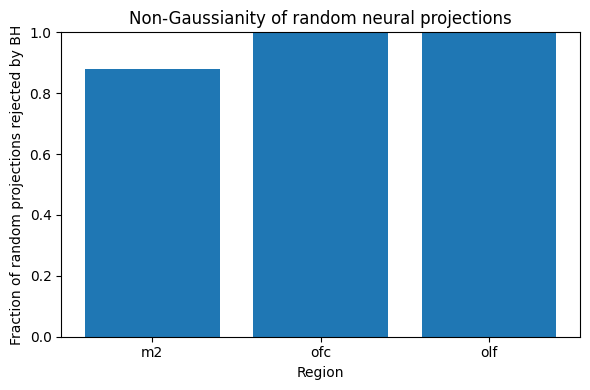

In [15]:
from pathlib import Path

summary_df = pd.DataFrame(region_summaries).T

outpath = Path(
    "/home/maria/mariakesa.github.io/livescience/16-06-2026/"
    "gaussian-projections/images/region_gaussianity.png"
)
outpath.parent.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(summary_df.index, summary_df["bh_rejection_fraction"])
ax.set_ylabel("Fraction of random projections rejected by BH")
ax.set_xlabel("Region")
ax.set_title("Non-Gaussianity of random neural projections")
ax.set_ylim(0, 1)

fig.tight_layout()
fig.savefig(outpath, dpi=300, bbox_inches="tight")

plt.show()

In [8]:
session = load_mouse_session(
    "/home/maria/Science/data/mouse_face_data/29117360/Mouse_Ephys_7.mat"
)

licks = session["licks"]
print(licks.columns.tolist())
print(licks.head())
print(licks.dtypes)

def find_columns(df, patterns):
    matches = []
    for col in df.columns:
        c = col.lower()
        if any(p.lower() in c for p in patterns):
            matches.append(col)
    return matches


candidate_cols = find_columns(
    licks,
    patterns=[
        "lick",
        "reward",
        "failure",
        "fail",
        "switch",
        "bout",
        "site",
        "strategy",
        "state",
        "value",
        "consecutive",
        "negative",
        "outcome",
    ],
)

candidate_cols

['time all licks', 'first lick', 'last lick', 'reward', 'last reward', 'trial number', 'consecutive failures']
   time all licks  first lick  last lick  reward  last reward  trial number  \
0             NaN         0.0        0.0     1.0          0.0           0.0   
1             NaN         0.0        0.0     0.0          0.0           0.0   
2             NaN         0.0        0.0     0.0          0.0           0.0   
3             NaN         0.0        0.0     0.0          0.0           0.0   
4             NaN         0.0        0.0     0.0          0.0           0.0   

   consecutive failures  
0                   NaN  
1                   NaN  
2                   NaN  
3                   NaN  
4                   NaN  
time all licks          float64
first lick              float64
last lick               float64
reward                  float64
last reward             float64
trial number            float64
consecutive failures    float64
dtype: object


['time all licks',
 'first lick',
 'last lick',
 'reward',
 'last reward',
 'consecutive failures']

In [10]:
from statsmodels.stats.diagnostic import lilliefors
from statsmodels.stats.multitest import multipletests
from scipy.stats import skew, kurtosis
import numpy as np
import pandas as pd


def test_random_projection_gaussianity_with_directions(
    X,
    n_directions=1000,
    alpha=0.05,
    seed=0,
):
    X = ensure_time_by_neurons(X)
    X = zscore_columns(X)

    valid_rows = np.isfinite(X).all(axis=1)
    X = X[valid_rows]

    n_time, n_neurons = X.shape

    W = sample_random_unit_directions(
        n_neurons=n_neurons,
        n_directions=n_directions,
        seed=seed,
    )

    Z = X @ W.T

    pvals = []
    test_stats = []
    skews = []
    excess_kurts = []

    for j in range(n_directions):
        z = Z[:, j]
        stat, pval = lilliefors(z, dist="norm")

        test_stats.append(stat)
        pvals.append(pval)
        skews.append(skew(z, bias=False))
        excess_kurts.append(kurtosis(z, fisher=True, bias=False))

    reject, pvals_bh, _, _ = multipletests(
        pvals,
        alpha=alpha,
        method="fdr_bh",
    )

    results_df = pd.DataFrame({
        "direction": np.arange(n_directions),
        "lilliefors_stat": test_stats,
        "p_value": pvals,
        "p_value_bh": pvals_bh,
        "reject_bh": reject,
        "is_gaussianish": ~reject,
        "skewness": skews,
        "excess_kurtosis": excess_kurts,
    })

    summary = {
        "n_time_bins": n_time,
        "n_neurons": n_neurons,
        "n_directions": n_directions,
        "alpha": alpha,
        "bh_rejection_fraction": float(np.mean(reject)),
        "gaussianish_fraction": float(np.mean(~reject)),
        "median_lilliefors_stat": float(np.median(test_stats)),
        "median_abs_skewness": float(np.median(np.abs(skews))),
        "median_abs_excess_kurtosis": float(np.median(np.abs(excess_kurts))),
    }

    return results_df, summary, W, X, valid_rows

m2_results, m2_summary, W, X_m2, valid_rows = test_random_projection_gaussianity_with_directions(
    session["m2"],
    n_directions=1000,
    alpha=0.05,
    seed=42,
)

m2_summary

def make_design_matrix_from_licks(licks, valid_rows=None, selected_cols=None):
    df = licks.copy()

    if valid_rows is not None:
        df = df.loc[np.asarray(valid_rows)].reset_index(drop=True)

    if selected_cols is None:
        numeric_df = df.select_dtypes(include=[np.number]).copy()
    else:
        numeric_df = df[selected_cols].copy()

    # Remove columns with all NaNs or no variance
    numeric_df = numeric_df.dropna(axis=1, how="all")

    good_cols = []
    for col in numeric_df.columns:
        x = numeric_df[col].to_numpy()
        if np.isfinite(x).sum() > 10 and np.nanstd(x) > 1e-8:
            good_cols.append(col)

    numeric_df = numeric_df[good_cols]

    # Fill remaining NaNs with column means
    numeric_df = numeric_df.apply(lambda s: s.fillna(s.mean()), axis=0)

    # Z-score predictors
    B = numeric_df.to_numpy(dtype=float)
    B = (B - B.mean(axis=0, keepdims=True)) / (B.std(axis=0, keepdims=True) + 1e-8)

    # Add intercept
    intercept = np.ones((B.shape[0], 1))
    B_with_intercept = np.concatenate([intercept, B], axis=1)

    colnames = ["intercept"] + list(numeric_df.columns)

    return B_with_intercept, colnames, numeric_df


B, design_cols, design_df = make_design_matrix_from_licks(
    session["licks"],
    valid_rows=valid_rows,
)

print(B.shape)
design_cols

def fit_neural_regression_directions(X, B, ridge=1e-3):
    """
    Fit X ≈ B Beta.

    X: time x neurons
    B: time x predictors

    Returns:
        Beta: predictors x neurons
    """
    BtB = B.T @ B
    reg = ridge * np.eye(BtB.shape[0])
    reg[0, 0] = 0.0  # do not regularize intercept

    Beta = np.linalg.solve(BtB + reg, B.T @ X)
    return Beta


Beta = fit_neural_regression_directions(X_m2, B, ridge=1e-3)

Beta.shape

def normalize_rows(A, eps=1e-12):
    return A / (np.linalg.norm(A, axis=1, keepdims=True) + eps)


def direction_alignment_to_regression_axes(W, Beta, design_cols, skip_intercept=True):
    """
    W: random directions, shape directions x neurons
    Beta: regression coefficients, shape predictors x neurons
    """
    if skip_intercept:
        Beta_use = Beta[1:]
        cols_use = design_cols[1:]
    else:
        Beta_use = Beta
        cols_use = design_cols

    Wn = normalize_rows(W)
    Bn = normalize_rows(Beta_use)

    # abs cosine: directions have arbitrary sign
    align = np.abs(Wn @ Bn.T)

    align_df = pd.DataFrame(
        align,
        columns=cols_use,
    )

    align_df["max_alignment"] = align_df[cols_use].max(axis=1)
    align_df["best_variable"] = align_df[cols_use].idxmax(axis=1)

    return align_df


align_df = direction_alignment_to_regression_axes(W, Beta, design_cols)
m2_compare = pd.concat([m2_results, align_df], axis=1)

m2_compare.head()

(1332, 8)


,direction,lilliefors_stat,p_value,p_value_bh,reject_bh,is_gaussianish,skewness,excess_kurtosis,time all licks,first lick,last lick,reward,last reward,trial number,consecutive failures,max_alignment,best_variable
0,0,0.035551,0.001000,0.001567,True,False,-0.005977,0.654892,0.048957,0.028426,0.003321,0.132546,0.064131,0.009879,0.048417,0.132546,reward
1,1,0.046319,0.001000,0.001567,True,False,0.397887,3.818978,0.102439,0.022019,0.082171,0.066676,0.007098,0.076198,0.017451,0.102439,time all licks
2,2,0.029422,0.013558,0.016738,True,False,-0.205366,1.077933,0.037607,0.033299,0.303782,0.169256,0.054690,0.168043,0.283619,0.303782,last lick
3,3,0.049441,0.001000,0.001567,True,False,0.891708,6.437476,0.039775,0.122877,0.283264,0.095378,0.006084,0.072808,0.241182,0.283264,last lick
4,4,0.030419,0.008641,0.010978,True,False,0.247456,0.280575,0.072680,0.139584,0.023666,0.112350,0.103933,0.057531,0.074155,0.139584,first lick


In [11]:
m2_compare.groupby("is_gaussianish")["max_alignment"].describe()

,count,mean,std,min,25%,50%,75%,max
is_gaussianish,,,,,,,,
False,880.0,0.195400,0.061461,0.043712,0.150534,0.188211,0.230213,0.452593
True,120.0,0.203167,0.059164,0.069369,0.157949,0.196155,0.248704,0.380910


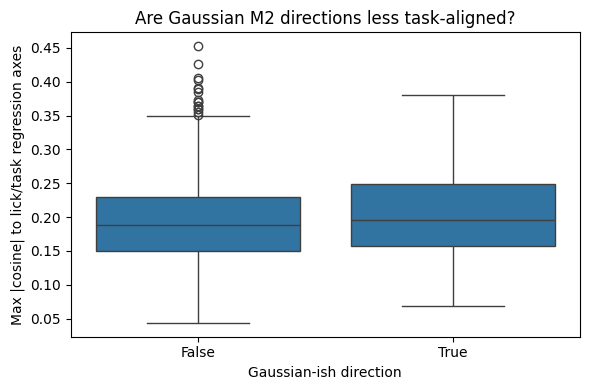

In [16]:
from pathlib import Path

outpath = Path(
    "/home/maria/mariakesa.github.io/livescience/16-06-2026/"
    "gaussian-projections/images/m2_gaussian_alignment.png"
)
outpath.parent.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(
    data=m2_compare,
    x="is_gaussianish",
    y="max_alignment",
    ax=ax,
)

ax.set_xlabel("Gaussian-ish direction")
ax.set_ylabel("Max |cosine| to lick/task regression axes")
ax.set_title("Are Gaussian M2 directions less task-aligned?")

fig.tight_layout()
fig.savefig(outpath, dpi=300, bbox_inches="tight")

plt.show()